In [1]:
import pandas as pd

# Load the building metadata
building_metadata = pd.read_csv('D:/MSAI/ML Semester Project/datasets/diversebuilding with weatherinformation/archive/building_metadata.csv')
print("Building Metadata Loaded Successfully!")
print(building_metadata.head())

# Here load the weather data 
weather_data = pd.read_csv('D:/MSAI/ML Semester Project/datasets/diversebuilding with weatherinformation/archive/weather_test.csv')
print("\nWeather Data Loaded Successfully!")
print(weather_data.head())

print("Run successfully")

Building Metadata Loaded Successfully!
   site_id  building_id primary_use  square_feet  year_built  floor_count
0        0            0   Education         7432      2008.0          NaN
1        0            1   Education         2720      2004.0          NaN
2        0            2   Education         5376      1991.0          NaN
3        0            3   Education        23685      2002.0          NaN
4        0            4   Education       116607      1975.0          NaN

Weather Data Loaded Successfully!
   site_id            timestamp  air_temperature  cloud_coverage  \
0        0  2017-01-01 00:00:00             17.8             4.0   
1        0  2017-01-01 01:00:00             17.8             2.0   
2        0  2017-01-01 02:00:00             16.1             0.0   
3        0  2017-01-01 03:00:00             17.2             0.0   
4        0  2017-01-01 04:00:00             16.7             2.0   

   dew_temperature  precip_depth_1_hr  sea_level_pressure  wind_direction

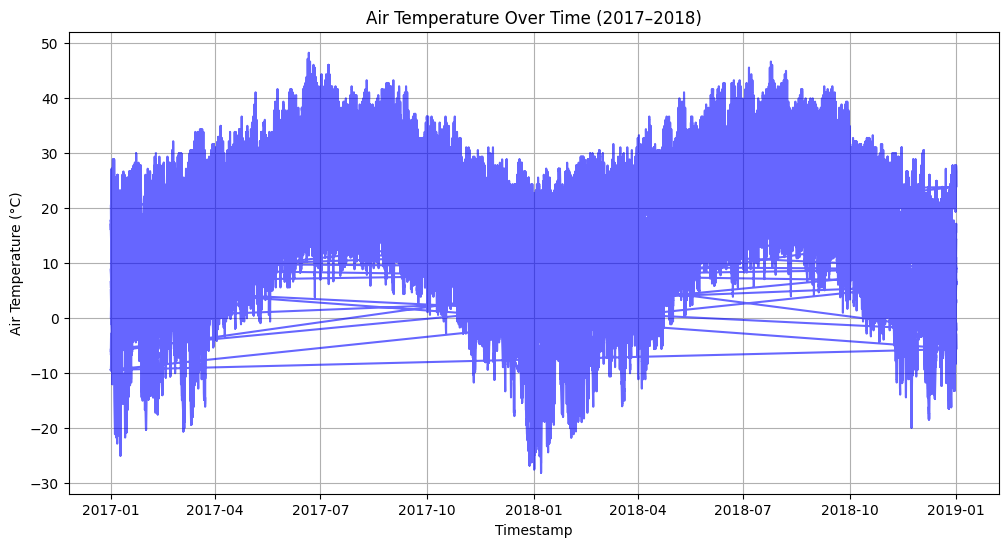

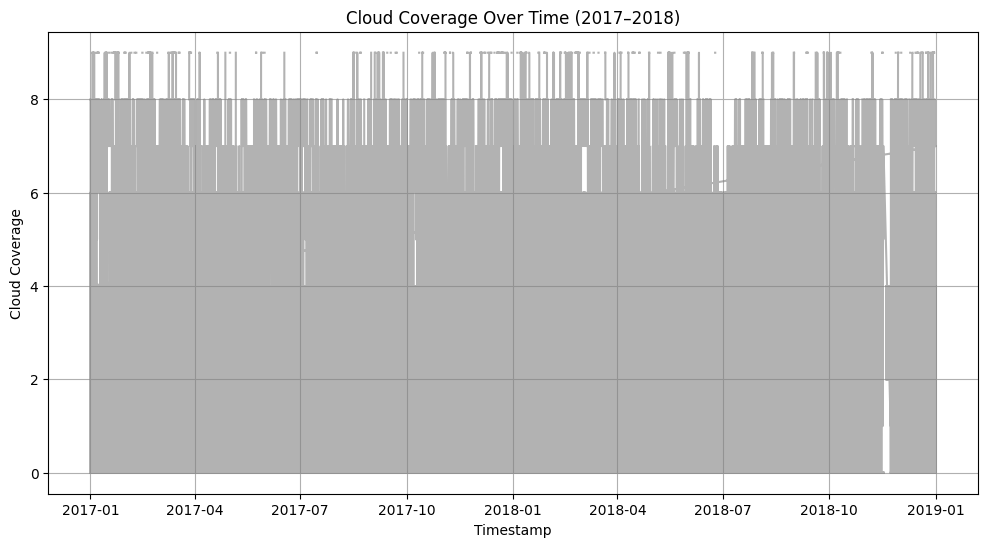

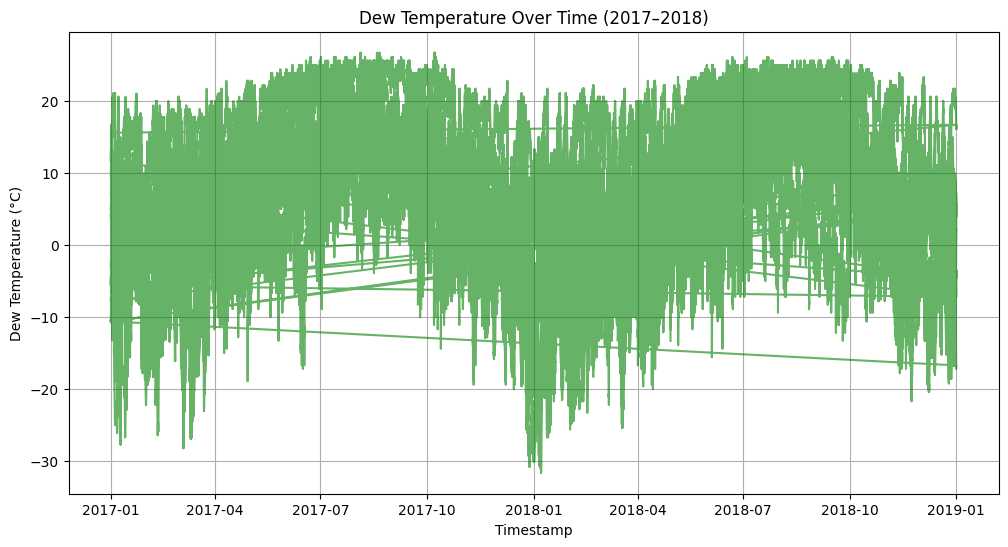

Summary Statistics for Weather Data:
       air_temperature  cloud_coverage  dew_temperature
count    277139.000000   136795.000000    276916.000000
mean         14.276863        2.187317         7.487658
std          10.741605        2.620627        10.153973
min         -28.100000        0.000000       -31.600000
25%           7.200000        0.000000         0.600000
50%          15.000000        2.000000         8.400000
75%          22.200000        4.000000        15.000000
max          48.300000        9.000000        26.700000
Run successfully


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

#plotting for understanding
# Plot air_temperature over time
plt.figure(figsize=(12, 6))
plt.plot(weather_data['timestamp'], weather_data['air_temperature'], color='blue', alpha=0.6)
plt.title('Air Temperature Over Time (2017–2018)')
plt.xlabel('Timestamp')
plt.ylabel('Air Temperature (°C)')
plt.grid()
plt.show()

# Plot cloud_coverage over time
plt.figure(figsize=(12, 6))
plt.plot(weather_data['timestamp'], weather_data['cloud_coverage'], color='gray', alpha=0.6)
plt.title('Cloud Coverage Over Time (2017–2018)')
plt.xlabel('Timestamp')
plt.ylabel('Cloud Coverage')
plt.grid()
plt.show()

# Plot dew_temperature over time
plt.figure(figsize=(12, 6))
plt.plot(weather_data['timestamp'], weather_data['dew_temperature'], color='green', alpha=0.6)
plt.title('Dew Temperature Over Time (2017–2018)')
plt.xlabel('Timestamp')
plt.ylabel('Dew Temperature (°C)')
plt.grid()
plt.show()

# Summary statistics of key weather features
print("Summary Statistics for Weather Data:")
print(weather_data[['air_temperature', 'cloud_coverage', 'dew_temperature']].describe())

print("Run successfully")

In [3]:
# Convert timestamp in weather data to datetime format
weather_data['timestamp'] = pd.to_datetime(weather_data['timestamp'])

# Verify conversion
print("\nWeather Data Timestamp Range:")
print(weather_data['timestamp'].min(), "to", weather_data['timestamp'].max())

print("Run successfully")


Weather Data Timestamp Range:
2017-01-01 00:00:00 to 2018-12-31 23:00:00
Run successfully


In [4]:
# Here merge building metadata with weather data
merged_data = building_metadata.merge(weather_data, on='site_id', how='inner')

# Check the merged dataset for no of features
print("\nMerged Data Preview:")
print(merged_data.head())

# Check the total record/ sample merged data Check the shape of the merged data
print(f"\nMerged Data Shape: {merged_data.shape}")

print("Run successfully")


Merged Data Preview:
   site_id  building_id primary_use  square_feet  year_built  floor_count  \
0        0            0   Education         7432      2008.0          NaN   
1        0            0   Education         7432      2008.0          NaN   
2        0            0   Education         7432      2008.0          NaN   
3        0            0   Education         7432      2008.0          NaN   
4        0            0   Education         7432      2008.0          NaN   

            timestamp  air_temperature  cloud_coverage  dew_temperature  \
0 2017-01-01 00:00:00             17.8             4.0             11.7   
1 2017-01-01 01:00:00             17.8             2.0             12.8   
2 2017-01-01 02:00:00             16.1             0.0             12.8   
3 2017-01-01 03:00:00             17.2             0.0             13.3   
4 2017-01-01 04:00:00             16.7             2.0             13.3   

   precip_depth_1_hr  sea_level_pressure  wind_direction  wind_s

In [7]:
# Check for missing values in the merged data as timely handling is necessary
missing_values = merged_data.isnull().sum()

print("\nMissing Values in Merged Data:")
print(missing_values)

print("Run successfully")


Missing Values in Merged Data:
site_id                      0
building_id                  0
primary_use                  0
square_feet                  0
year_built            13531915
floor_count           19109158
timestamp                    0
air_temperature          10534
cloud_coverage        11755894
dew_temperature          26596
precip_depth_1_hr      5100401
sea_level_pressure     1983259
wind_direction         1315776
wind_speed               44874
dtype: int64
Run successfully


In [5]:
# As year_built and floor_count columns with excessive missing value so drop the columns. Moreover, floor count is also covered in sqaure feet column

data_after_dropping = merged_data.drop(columns=['year_built', 'floor_count'])

# Confirm the dropping columns
print(f"Shape of Data After Dropping 'year_built' and 'floor_count': {data_after_dropping.shape}")

print("Run successfully")

Shape of Data After Dropping 'year_built' and 'floor_count': (25273986, 12)
Run successfully


In [8]:
'''Data preprocessing to handle missing value particularly for weather columns as crucial in preparing datasets for ML model to avoids errors 
from missing data as many models cannot handle missing values directly and missing data can be biased or lead to inaccuracies.'''

# Fill missing values in weather-related columns
weather_columns = ['air_temperature', 'dew_temperature', 'sea_level_pressure', 'wind_direction', 'wind_speed']
for col in weather_columns:
    merged_data[col] = merged_data[col].fillna(merged_data[col].mean())

# Handle high-missing columns
merged_data['cloud_coverage'] = merged_data['cloud_coverage'].fillna(0)  
merged_data['precip_depth_1_hr'] = merged_data['precip_depth_1_hr'].fillna(0) 

# Verify missing values after handling
missing_values_after = merged_data.isnull().sum()
print("\nMissing Values After Handling:")
print(missing_values_after)

print("Run successfully")


Missing Values After Handling:
site_id                      0
building_id                  0
primary_use                  0
square_feet                  0
year_built            13531915
floor_count           19109158
timestamp                    0
air_temperature              0
cloud_coverage               0
dew_temperature              0
precip_depth_1_hr            0
sea_level_pressure           0
wind_direction               0
wind_speed                   0
dtype: int64
Run successfully


In [9]:
# Drop 'year_built' and 'floor_count' columns
merged_data = merged_data.drop(columns=['year_built', 'floor_count'])

# Check the shape of the data after dropping these columns
print(f"Shape of Data After Dropping 'year_built' and 'floor_count': {merged_data.shape}")

print("Run successfully")

Shape of Data After Dropping 'year_built' and 'floor_count': (25273986, 12)
Run successfully


In [ ]:
'''Initially tested on sample of 10% of the 25273986 samples
# Randomly sample 10% of the merged dataset
sampled_data = merged_data.sample(frac=0.1, random_state=42)

# Check the shape of the sampled data
print(f"Shape of Sampled Data (10%): {sampled_data.shape}")

# Save the sampled dataset
sampled_data.to_csv('D:/MSAI/ML Semester Project/datasets/diversebuilding with weatherinformation/archive/sampled_dataset_10_percent.csv', index=False)
print("Sampled dataset saved successfully as 'sampled_dataset_10_percent.csv'")

print("Run successfully")'''

In [10]:
# Now tested on sample approximately 5 million rows (20% of the merged data)
sampled_data_large = merged_data.sample(frac=0.2, random_state=42)

# Check the shape of the sampled data
print(f"Shape of Sampled Data (20%): {sampled_data_large.shape}")

# Save the new sampled dataset
sampled_data_large.to_csv('D:/MSAI/ML Semester Project/datasets/diversebuilding with weatherinformation/archive/sampled_dataset_5_million.csv', index=False)
print("Sampled dataset saved successfully as 'sampled_dataset_5_million.csv'")
print("Run successfully")

Shape of Sampled Data (20%): (5054797, 12)
Sampled dataset saved successfully as 'sampled_dataset_5_million.csv'
Run successfully


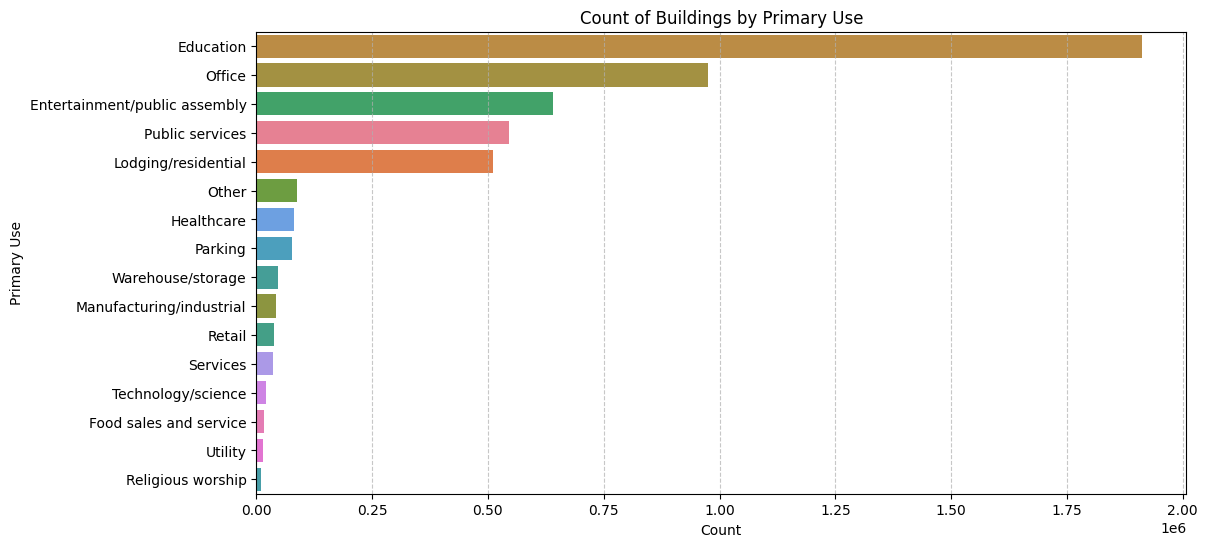

Run successfully


In [11]:
#Graphical view of diverse building datasets contribution
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the count of buildings by primary_use without warning
plt.figure(figsize=(12, 6))
sns.countplot(data=sampled_data_large, y='primary_use', order=sampled_data_large['primary_use'].value_counts().index, hue='primary_use', legend=False)
plt.title('Count of Buildings by Primary Use')
plt.xlabel('Count')
plt.ylabel('Primary Use')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("Run successfully")

In [12]:
# Check the available features in the dataset
print("Features in the dataset:")
print(sampled_data_large.columns)

print("Run successfully")

Features in the dataset:
Index(['site_id', 'building_id', 'primary_use', 'square_feet', 'timestamp',
       'air_temperature', 'cloud_coverage', 'dew_temperature',
       'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction',
       'wind_speed'],
      dtype='object')
Run successfully


In [13]:
# Get summary statistics of the dataset
print("Summary Statistics of the Dataset:")
print(sampled_data_large.describe())

print("Run successfully")

Summary Statistics of the Dataset:
            site_id   building_id   square_feet  \
count  5.054797e+06  5.054797e+06  5.054797e+06   
mean   6.939718e+00  7.228499e+02  9.210255e+04   
min    0.000000e+00  0.000000e+00  2.830000e+02   
25%    3.000000e+00  3.610000e+02  2.294900e+04   
50%    5.000000e+00  7.230000e+02  5.767300e+04   
75%    1.300000e+01  1.085000e+03  1.156760e+05   
max    1.500000e+01  1.448000e+03  8.750000e+05   
std    4.997082e+00  4.179335e+02  1.107185e+05   

                           timestamp  air_temperature  cloud_coverage  \
count                        5054797     5.054797e+06    5.054797e+06   
mean   2017-12-31 11:51:17.138646528     1.554357e+01    1.251938e+00   
min              2017-01-01 00:00:00    -2.810000e+01    0.000000e+00   
25%              2017-07-02 04:00:00     8.300000e+00    0.000000e+00   
50%              2017-12-31 13:00:00     1.610000e+01    0.000000e+00   
75%              2018-07-01 18:00:00     2.340000e+01    2.000000e+

In [14]:
# Once again confirm for missing values in each feature
print("Missing Values by Feature:")
print(sampled_data_large.isnull().sum())
print("Run successfully")

Missing Values by Feature:
site_id               0
building_id           0
primary_use           0
square_feet           0
timestamp             0
air_temperature       0
cloud_coverage        0
dew_temperature       0
precip_depth_1_hr     0
sea_level_pressure    0
wind_direction        0
wind_speed            0
dtype: int64
Run successfully


In [15]:
'''Extract meaningful time-based features from the timestamp column to enhance the predictive power of machine learning models by 
transforming raw data into informative inputs. Moreover, after extracting informative features, the original  timestamp is removed.'''

sampled_data_large['timestamp'] = pd.to_datetime(sampled_data_large['timestamp'])
sampled_data_large['hour'] = sampled_data_large['timestamp'].dt.hour 
sampled_data_large['day_of_week'] = sampled_data_large['timestamp'].dt.dayofweek
sampled_data_large['month'] = sampled_data_large['timestamp'].dt.month

# Drop the original timestamp column
sampled_data_large = sampled_data_large.drop(columns=['timestamp'])

print("Time-based features added successfully!")

print("Run successfully")

Time-based features added successfully!
Run successfully


In [16]:
# Get summary statistics of the dataset whether hour, week and month extracted or not
print("Summary Statistics of the Dataset:")
print(sampled_data_large.describe())

print("Run successfully")

Summary Statistics of the Dataset:
            site_id   building_id   square_feet  air_temperature  \
count  5.054797e+06  5.054797e+06  5.054797e+06     5.054797e+06   
mean   6.939718e+00  7.228499e+02  9.210255e+04     1.554357e+01   
std    4.997082e+00  4.179335e+02  1.107185e+05     1.069950e+01   
min    0.000000e+00  0.000000e+00  2.830000e+02    -2.810000e+01   
25%    3.000000e+00  3.610000e+02  2.294900e+04     8.300000e+00   
50%    5.000000e+00  7.230000e+02  5.767300e+04     1.610000e+01   
75%    1.300000e+01  1.085000e+03  1.156760e+05     2.340000e+01   
max    1.500000e+01  1.448000e+03  8.750000e+05     4.830000e+01   

       cloud_coverage  dew_temperature  precip_depth_1_hr  sea_level_pressure  \
count    5.054797e+06     5.054797e+06       5.054797e+06        5.054797e+06   
mean     1.251938e+00     8.214835e+00       7.353239e-01        1.016479e+03   
std      2.231249e+00     1.027532e+01       7.735937e+00        7.188385e+00   
min      0.000000e+00    -3.

In [18]:
# Check the columns in sampled_data
print("Available columns in the dataset:")
print(sampled_data_large.columns)

print("Run successfully")

Available columns in the dataset:
Index(['site_id', 'building_id', 'primary_use', 'square_feet',
       'air_temperature', 'cloud_coverage', 'dew_temperature',
       'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction',
       'wind_speed', 'hour', 'day_of_week', 'month'],
      dtype='object')
Run successfully


In [19]:
'''Helps understand the relationships between features and the target variable in a controlled environment 
for comparing algorithms and testing model performance.'''

import numpy as np

# Generate synthetic meter readings
sampled_data_large['meter_reading'] = (
    0.1 * sampled_data_large['square_feet'] +  # Base energy use proportional to size
    5 * np.maximum(sampled_data_large['air_temperature'], 0) +  # Temperature effect
    np.random.normal(0, 10, len(sampled_data_large))  # Add random variability
)

# Verify the dataset now includes meter_reading
print("Updated Columns in the Dataset:")
print(sampled_data_large.columns)

print("Run successfully")

Updated Columns in the Dataset:
Index(['site_id', 'building_id', 'primary_use', 'square_feet',
       'air_temperature', 'cloud_coverage', 'dew_temperature',
       'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction',
       'wind_speed', 'hour', 'day_of_week', 'month', 'meter_reading'],
      dtype='object')
Run successfully


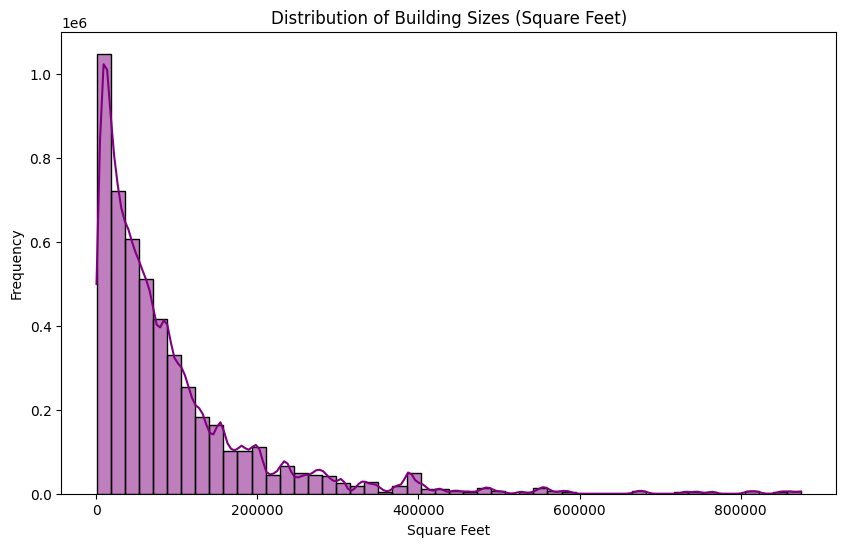

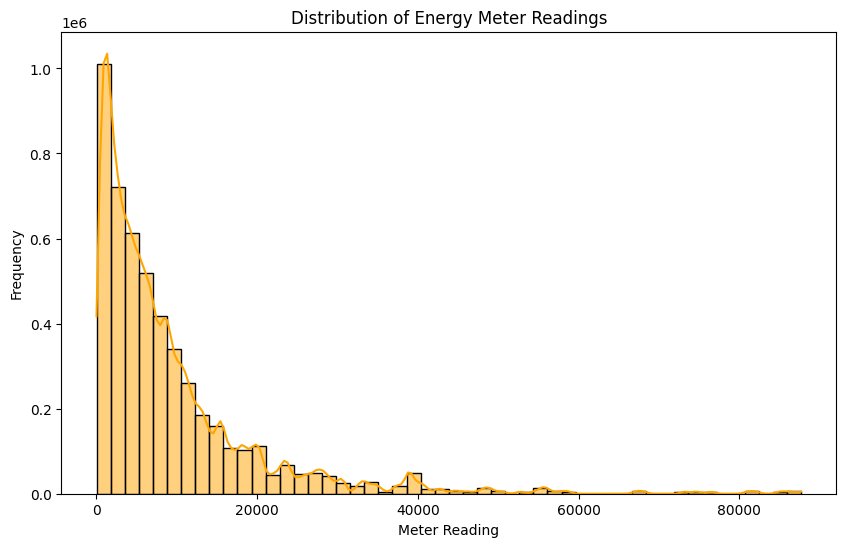

In [20]:
# Mostly buildings are small in size only a few very large
import seaborn as sns

# Distribution of Square Feet
plt.figure(figsize=(10, 6))
sns.histplot(sampled_data_large['square_feet'].dropna(), bins=50, kde=True, color='purple')
plt.title('Distribution of Building Sizes (Square Feet)')
plt.xlabel('Square Feet')
plt.ylabel('Frequency')
plt.show()

# Most buildings use less energy with only a few outliers consuming very high energy
# Distribution of Meter Reading
plt.figure(figsize=(10, 6))
sns.histplot(sampled_data_large['meter_reading'].dropna(), bins=50, kde=True, color='orange')
plt.title('Distribution of Energy Meter Readings')
plt.xlabel('Meter Reading')
plt.ylabel('Frequency')
plt.show()

'''Will be handled through splitting of data into train/ testing and random forest/ XGBoost is already robust to outliers and can handle
skewed data better than linear models and XGBoost handles skewed data better than random forest due to its gradient boosting.
Moreover, to ensure the model performed well for both the majority and minority cases, will be evaluated it with the right metrices 
like MAE, RMSE and R and sqrt hyperparameter, subsample=0.8 (80% of the training data for each boosting iteration randomly )'''

In [21]:
# Splitting data into 80% training and 20% testing
from sklearn.model_selection import train_test_split

# Separate features (X) and target variable (y)
X = sampled_data_large.drop(columns=['meter_reading'])  # Features
y = sampled_data_large['meter_reading']  # Target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the shapes of the splits
print(f"Training Data Shape (X_train): {X_train.shape}")
print(f"Testing Data Shape (X_test): {X_test.shape}")
print(f"Training Target Shape (y_train): {y_train.shape}")
print(f"Testing Target Shape (y_test): {y_test.shape}")

print("Run successfully")

Training Data Shape (X_train): (4043837, 14)
Testing Data Shape (X_test): (1010960, 14)
Training Target Shape (y_train): (4043837,)
Testing Target Shape (y_test): (1010960,)
Run successfully


In [22]:
# Check the columns in the sampled dataset
print("Columns in the sampled dataset:")
print(sampled_data_large.columns)

print("Run successfully")

Columns in the sampled dataset:
Index(['site_id', 'building_id', 'primary_use', 'square_feet',
       'air_temperature', 'cloud_coverage', 'dew_temperature',
       'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction',
       'wind_speed', 'hour', 'day_of_week', 'month', 'meter_reading'],
      dtype='object')
Run successfully


In [23]:
# Identify non-numeric columns in the features
non_numeric_columns = X_train.select_dtypes(include=['object']).columns
print("Non-numeric columns in the dataset:")
print(non_numeric_columns)


print("Run successfully")

Non-numeric columns in the dataset:
Index(['primary_use'], dtype='object')
Run successfully


In [24]:
# Numerical features required for Random Forest as here convert categorical value into numerical value.
from sklearn.preprocessing import LabelEncoder
# Encode 'primary_use' using Label Encoding
label_encoder = LabelEncoder()
X_train['primary_use'] = label_encoder.fit_transform(X_train['primary_use'])
X_test['primary_use'] = label_encoder.transform(X_test['primary_use'])  # Apply the same transformation to test data

print("Encoded 'primary_use' successfully!")
print("Classes in 'primary_use':", label_encoder.classes_)


print("Run successfully")

Encoded 'primary_use' successfully!
Classes in 'primary_use': ['Education' 'Entertainment/public assembly' 'Food sales and service'
 'Healthcare' 'Lodging/residential' 'Manufacturing/industrial' 'Office'
 'Other' 'Parking' 'Public services' 'Religious worship' 'Retail'
 'Services' 'Technology/science' 'Utility' 'Warehouse/storage']
Run successfully


In [25]:
# Random forest model training
from sklearn.ensemble import RandomForestRegressor
# Initialize the Random Forest Regressor with optimized hyperparameters
rf_model = RandomForestRegressor(
    n_estimators=200,       # As tested with different number of tree for stability so 200 is final.
    max_depth=15,           # Limit tree depth to prevent overfitting (10-30 is recommended)
    min_samples_split=20,   # Prevents overfitting by stopping unnecessary splits on small sample or where sample has only less number
    min_samples_leaf=10,    # prevent the tree from creating too many small, unreliable branches and ensures that each decision has enough data to be meaningful. 
    max_features="sqrt",    # Model faster and more robust by avoiding reliance on specific features at each split to prevent overfitting
    random_state=42,        # For reproducibility (shuffle happens the same way every time. like training 1,2,3,4,5,6 and test 9, 10)
    n_jobs=-1               # Use all CPU cores for faster training
)

# Train the Random Forest model
rf_model.fit(X_train, y_train)

print("Random Forest model training completed with optimized hyperparameters!")

print("Run successfully")

Random Forest model training completed with optimized hyperparameters!
Run successfully


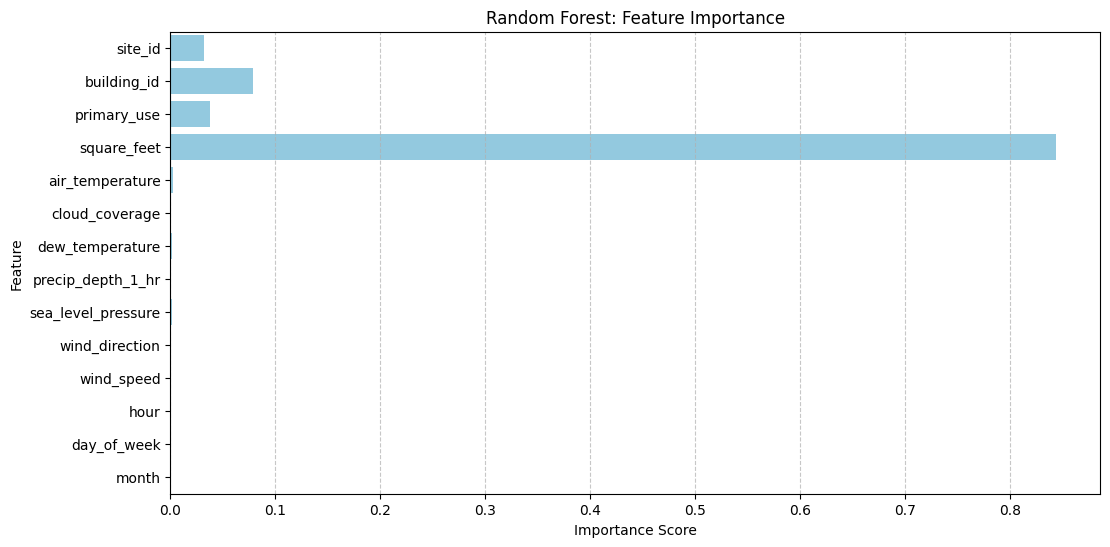

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Importance Plot for Random Forest
importances = rf_model.feature_importances_
feature_names = X_train.columns

plt.figure(figsize=(12, 6))
sns.barplot(x=importances, y=feature_names, color='skyblue')
plt.title('Random Forest: Feature Importance') #features contribute the most to predictions.
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5  # Calculate RMSE manually
r2 = r2_score(y_test, y_pred)

# Print the metrics
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R² Score: {r2}")

 

print("Run successfully")

Mean Absolute Error (MAE): 615.9597902421646
Root Mean Squared Error (RMSE): 897.3742955391873
R² Score: 0.9934153266399859
Run successfully


In [28]:
#If the training R² is much higher than the test R², it indicates overfitting.
train_r2 = rf_model.score(X_train, y_train)
test_r2 = rf_model.score(X_test, y_test)

print(f"Training R²: {train_r2}")
print(f"Testing R²: {test_r2}")

print("Run successfully")

Training R²: 0.993532133391493
Testing R²: 0.9934153266399859
Run successfully


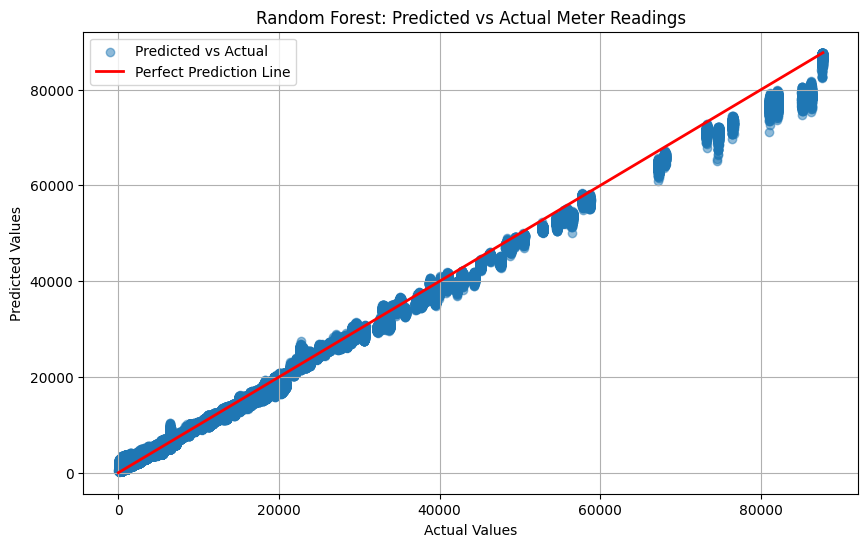

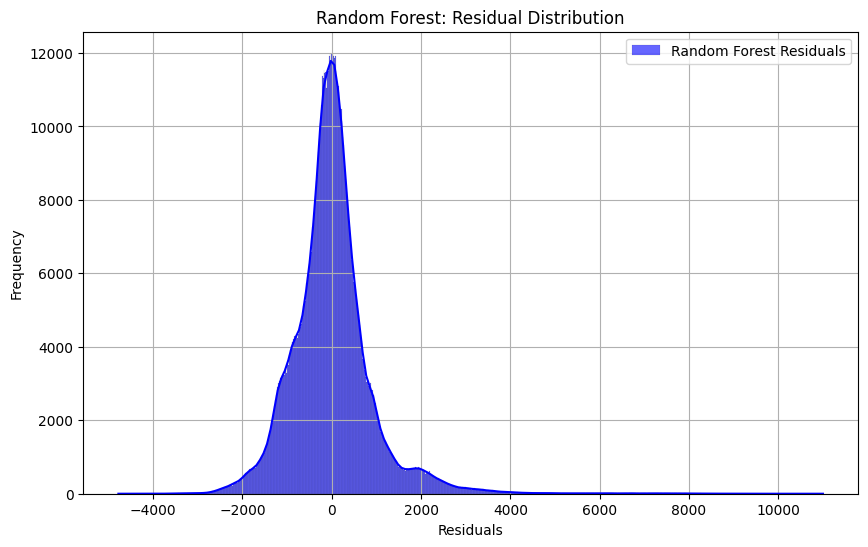

Run successfully


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Predicted vs Actual Plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2, label="Perfect Prediction Line")
plt.title('Random Forest: Predicted vs Actual Meter Readings')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend(loc="upper left")  # Set legend location
plt.grid()
plt.show()

'''Most predicted values are close to the actual values (points near the red line).'''
# 2. Residual Distribution
plt.figure(figsize=(10, 6))
sns.histplot(y_test - y_pred, kde=True, color='blue', label='Random Forest Residuals', alpha=0.6)
plt.title('Random Forest: Residual Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.legend(loc="upper right")  # Set legend location
plt.grid()
plt.show()


print("Run successfully")

'''The residuals are small, centered around zero, and symmetrically distributed, indicating no bias or large errors.'''


In [30]:
from xgboost import XGBRegressor

# Initialize the XGBoost Regressor with optimized hyperparameters
xgb_model = XGBRegressor(
    n_estimators=200,           # Number of boosting rounds (trees)
    max_depth=15,               # Maximum depth of each tree
    learning_rate=0.05,         # Smaller learning rate for stability
    subsample=0.8,              # Use 80% of data for each boosting round randomley to prevent memorizing the same data
    colsample_bytree=0.8,       # Use 80% of features this force the model to consider different features combinations in each tree, improving robustness.
    gamma=0.1,                  # If splitting a node does not reduce the loss by at least 0.1, the split won't happen to prevent over complicating the tree by ignoring minor improvements that do not add much value
    reg_alpha=0.5,              # L1 regularization to reduce overfitting (shrink the less important features weight towards zero to make the model simpler and prevents overfitting like wind direction 
    reg_lambda=1.0,             # L2 regularization to reduce overfitting (a penalty to large weights, forcing the model to reduce their size, which helps improve generalization and prevents overfitting.(sqft=50, air temp=5, wind speed=0.1, means the model relies heavily on this feature. 1.0 mean 30, 4.5 and 0.1
    random_state=42,            # For reproducibility
    n_jobs=-1                   # Use all CPU cores for faster training
)

# Train the XGBoost model
xgb_model.fit(X_train, y_train)

print("XGBoost model training completed with optimized hyperparameters!")

print("Run successfully")

XGBoost model training completed with optimized hyperparameters!
Run successfully


In [ ]:
'''from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize the XGBoost Regressor
xgb_model = XGBRegressor(
    n_estimators=500,      # Number of trees
    max_depth=20,          # Maximum tree depth
    learning_rate=0.01,     # Step size for weight updates
    subsample=0.8,         # Fraction of samples used for each tree
    colsample_bytree=0.8,  # Fraction of features used for each tree
    random_state=42        # For reproducibility
)

# Train the XGBoost model
xgb_model.fit(X_train, y_train)

print("Run successfully")'''

In [31]:

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = mean_squared_error(y_test, y_pred_xgb) ** 0.5
r2_xgb = r2_score(y_test, y_pred_xgb)

# Print evaluation metrics
print("XGBoost Model Performance:")
print(f"Mean Absolute Error (MAE): {mae_xgb}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb}")
print(f"R² Score: {r2_xgb}")

print("Run successfully")

XGBoost Model Performance:
Mean Absolute Error (MAE): 27.279453412349895
Root Mean Squared Error (RMSE): 69.2238333733424
R² Score: 0.9999608169466025
Run successfully


In [32]:
train_r2_xgb = xgb_model.score(X_train, y_train)
test_r2_xgb = xgb_model.score(X_test, y_test)

print(f"Training R²: {train_r2_xgb}")
print(f"Testing R²: {test_r2_xgb}")

print("Run successfully")

Training R²: 0.9999863103129663
Testing R²: 0.9999608169466025
Run successfully


C:\Users\Mega Providers\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


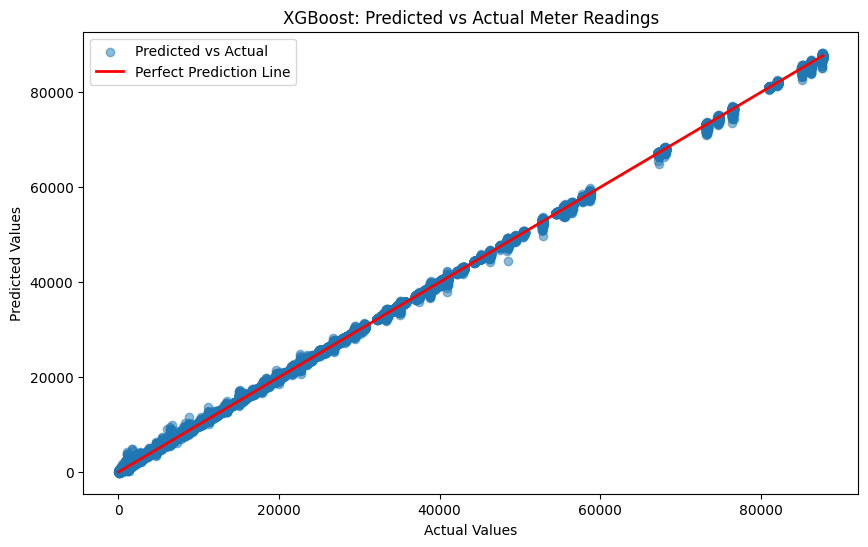

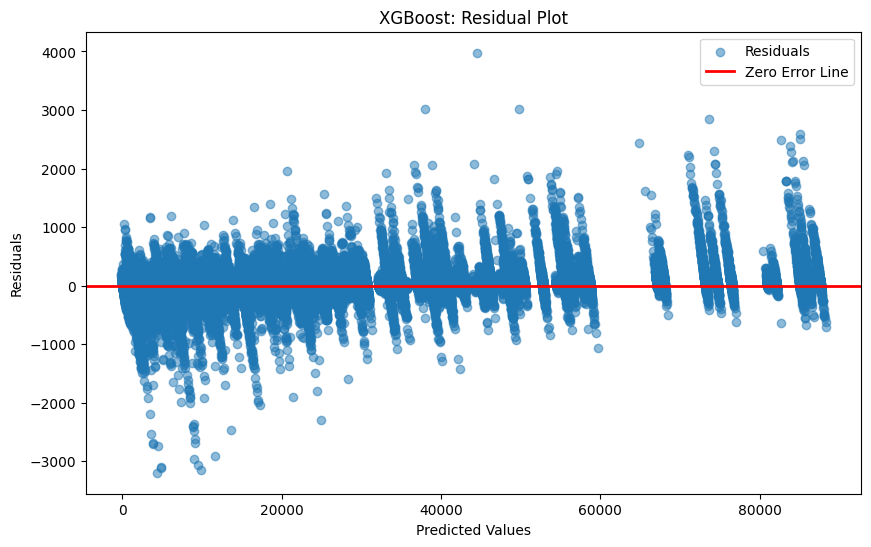

Run successfully


In [33]:
import matplotlib.pyplot as plt

# Predicted vs Actual Plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.5, label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2, label="Perfect Prediction Line")
plt.title('XGBoost: Predicted vs Actual Meter Readings')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.show()

# Residual Plot
residuals_xgb = y_test - y_pred_xgb
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_xgb, residuals_xgb, alpha=0.5, label="Residuals")
plt.axhline(0, color='red', linewidth=2, label="Zero Error Line")
plt.title('XGBoost: Residual Plot')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.legend()
plt.show()
print("Run successfully")

'''
if residual = 0 (model prediction is perfect) : 
If residual > 0 (Model underpredicted mean predicted value is smaller than actual value),
if residual < 0 (Overpredicted mean predicted value is larger than the actual value)
'''

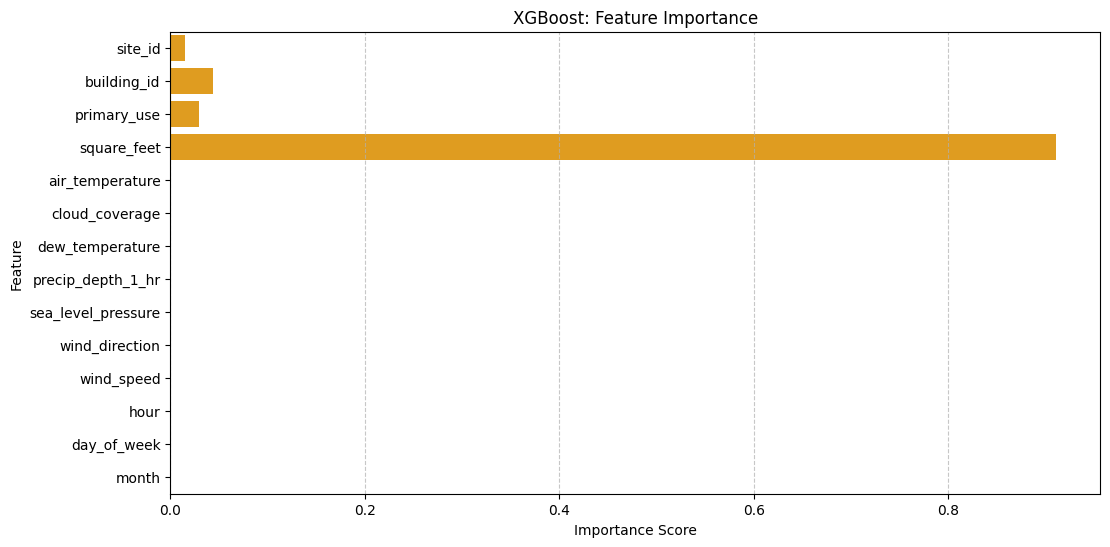

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Importance Plot for XGBoost
xgb_importances = xgb_model.feature_importances_
feature_names = X_train.columns

plt.figure(figsize=(12, 6))
sns.barplot(x=xgb_importances, y=feature_names, color='orange')  # Use a single color instead of palette
plt.title('XGBoost: Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()



In [35]:
#Now LSTM model 
# Import libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt


print("Run successfully")

Run successfully


In [36]:
print("Columns in the dataset:")
print(sampled_data_large.columns)


Columns in the dataset:
Index(['site_id', 'building_id', 'primary_use', 'square_feet',
       'air_temperature', 'cloud_coverage', 'dew_temperature',
       'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction',
       'wind_speed', 'hour', 'day_of_week', 'month', 'meter_reading'],
      dtype='object')


In [37]:
# Define features and target
features = [
    'square_feet', 'air_temperature', 'cloud_coverage', 'dew_temperature',
    'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction', 'wind_speed',
    'hour', 'day_of_week', 'month'
]
target = 'meter_reading'

print("Features and target defined successfully!")
print(f"Features: {features}")
print(f"Target: {target}")


Features and target defined successfully!
Features: ['square_feet', 'air_temperature', 'cloud_coverage', 'dew_temperature', 'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction', 'wind_speed', 'hour', 'day_of_week', 'month']
Target: meter_reading


In [38]:
from sklearn.preprocessing import MinMaxScaler

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Scale the features and target
data_scaled = scaler.fit_transform(sampled_data_large[features + [target]])

print(f"Data scaled successfully! Shape: {data_scaled.shape}")

print("Run successfully")

Data scaled successfully! Shape: (5054797, 12)
Run successfully


'from sklearn.preprocessing import MinMaxScaler\n\n# Initialize MinMaxScaler\nscaler = MinMaxScaler()\n\n# Scale the features and target\ndata_scaled = scaler.fit_transform(sampled_data_large[features + [target]])\n\nprint(f"Data scaled successfully! Shape: {data_scaled.shape}")\n\nprint("Run successfully")'

In [39]:
# Verify the number of columns matches
print(f"Shape of scaled data: {data_scaled.shape}")  # Should match (rows, len(features) + 1)
print(f"Number of feature columns: {len(features + [target])}")

print("Run successfully")

Shape of scaled data: (5054797, 12)
Number of feature columns: 12
Run successfully


In [40]:
from sklearn.model_selection import train_test_split

# Split the scaled data into training and testing sets
train_data, test_data = train_test_split(data_scaled, test_size=0.2, random_state=42, shuffle=False)

print(f"Training data shape: {train_data.shape}")
print(f"Testing data shape: {test_data.shape}")


print("Run successfully")

Training data shape: (4043837, 12)
Testing data shape: (1010960, 12)
Run successfully


In [41]:
'''Convert a dataset into sequences/ preparing data for training and testing time series models like LSTM that work with sequential data. 
For every 24 (timesteps) of past data, the code sets the target value as the value at the next time step so this allows the model 
to learn how previous data influences future outcomes.'''

import numpy as np
# Function to create sequences
def create_sequences(data, time_steps):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i + time_steps, :-1])  # All columns except the target
        y.append(data[i + time_steps, -1])    # The target column
    return np.array(X), np.array(y)

# Define the number of time steps
time_steps = 24  # E.g., 24 hours

# Create sequences for training and testing data
X_train, y_train = create_sequences(train_data, time_steps)
X_test, y_test = create_sequences(test_data, time_steps)

# Print the shapes of the generated sequences
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")  
print(f"X_test shape: {X_test.shape}")   
print(f"y_test shape: {y_test.shape}")

print("Run successfully")

X_train shape: (4043813, 24, 11)
y_train shape: (4043813,)
X_test shape: (1010936, 24, 11)
y_test shape: (1010936,)
Run successfully


In [ ]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Define the LSTM model
lstm_model = Sequential([
    Input(shape=(24, 11)),          # Input shape: 24 time steps, 11 features
    LSTM(128, activation='relu', return_sequences=False),  # LSTM layer with 128 units
    Dropout(0.2),                  # Dropout for regularization
    Dense(64, activation='relu'),  # Fully connected layer
    Dropout(0.2),                  # Dropout for regularization
    Dense(1)                       # Output layer for regression
])

# To compile the LSTM model with appropriate settings for training.Commonly used for time-series model where goal is to predict continuous value
lstm_model.compile(
    optimizer=Adam(learning_rate=0.0005),  # 0.0005 a small learning rate is chosen to ensure stable and accurate training and to avoid skipping over the minimum of the loss function and to take smaller steps, so it may require more iterations to converge.
    loss="mse",                           # Mean Squared Error for regression
    metrics=["mae"]                       # Mean Absolute Error as an additional metric
)

print("LSTM Model Defined and Compiled Successfully!")

# Define EarlyStopping callback
early_stopping = EarlyStopping(
    monitor="val_loss",            # Monitor validation loss
    patience=5,                    # Stop after 5 epochs without improvement
    restore_best_weights=True      # Restore the best weights after stopping
)

# Train the LSTM model
history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),  # Use explicit validation data
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

print("LSTM Model Training Completed Successfully!")

print("Run successfully")



LSTM Model Defined and Compiled Successfully!
Epoch 1/30
 94853/126370 ━━━━━━━━━━━━━━━━━━━━ 7:09 14ms/step - loss: 0.0160 - mae: 0.0835 

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Generate predictions
y_pred = lstm_model.predict(X_test).flatten()

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("LSTM Model Performance:")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

print("Run successfully")

In [ ]:
'''diagnose model performance by visualizing prediction errors.if residuals centered around 0(indicating no systematic bias in predictions), '''
# Calculate residuals (errors)
residuals = y_test.flatten() - y_pred.flatten()

# Plot Residual Distribution
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=50, color='purple', alpha=0.7, label='Residuals')
plt.title("Residual Distribution")
plt.xlabel("Residual Value")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
# Scatter plot of Actual vs. Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test.flatten(), y_pred.flatten(), alpha=0.6, color='green')
plt.plot([0, 1], [0, 1], 'r--', transform=plt.gca().transAxes, label="Perfect Prediction Line")
plt.title("Actual vs. Predicted Scatter Plot")
plt.xlabel("Actual Values (Normalized)")
plt.ylabel("Predicted Values (Normalized)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Flatten predictions (if they are not already)
y_pred_flat = y_pred.flatten()

# Plot a subset of data points for better visualization
subset = 1000  # Adjust the number of points to plot
indices = np.arange(min(len(y_test), subset))

plt.figure(figsize=(12, 6))

# Plot actual values
plt.plot(indices, y_test[:subset], label="Actual Values", color='blue', alpha=0.7)

# Plot predicted values
plt.plot(indices, y_pred_flat[:subset], label="Predicted Values", color='orange', alpha=0.7)

# Add labels, legend, and title
plt.xlabel("Sample Index")
plt.ylabel("Meter Reading")
plt.title("Comparison of Actual and Predicted Values")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# De-normalize the predictions and actual values
y_pred_original = y_pred_flat * (sampled_data_large['meter_reading'].max() - sampled_data_large['meter_reading'].min()) + sampled_data_large['meter_reading'].min()
y_test_original = y_test * (sampled_data_large['meter_reading'].max() - sampled_data_large['meter_reading'].min()) + sampled_data_large['meter_reading'].min()

# Print some statistics to verify
print("De-Normalized Predictions and Actuals:")
print(f"Predicted (Min, Max): ({y_pred_original.min()}, {y_pred_original.max()})")
print(f"Actual (Min, Max): ({y_test_original.min()}, {y_test_original.max()})")

# Plot a subset of the results for better visualization
import matplotlib.pyplot as plt
import numpy as np

subset = 1000  # Plot only the first 1000 data points for clarity
indices = np.arange(min(len(y_test_original), subset))

plt.figure(figsize=(12, 6))

# Plot actual values
plt.plot(indices, y_test_original[:subset], label="Actual Values", color='blue', alpha=0.7)

# Plot predicted values
plt.plot(indices, y_pred_original[:subset], label="Predicted Values", color='orange', alpha=0.7)

# Add labels, legend, and title
plt.xlabel("Sample Index")
plt.ylabel("Meter Reading")
plt.title("Comparison of De-Normalized Actual and Predicted Values")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Run successfully")

In [ ]:

# Check the range and basic statistics of the original target column
print("Original 'meter_reading' statistics:")
print(f"Minimum: {sampled_data_large['meter_reading'].min()}")
print(f"Maximum: {sampled_data_large['meter_reading'].max()}")
print(f"Mean: {sampled_data_large['meter_reading'].mean()}")

# Assuming 'data_scaled' includes the scaled features and the target as the last column
# Extract the scaled 'meter_reading' from the last column
scaled_meter_reading = data_scaled[:, -1]

# Check the range and basic statistics of the scaled target
print("\nScaled 'meter_reading' statistics:")
print(f"Minimum: {scaled_meter_reading.min()}")
print(f"Maximum: {scaled_meter_reading.max()}")
print(f"Mean: {scaled_meter_reading.mean()}")

print("Run successfully")

In [ ]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# Calculate MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    """
    Calculate the Mean Absolute Percentage Error (MAPE).
    Note: MAPE is not well-defined when y_true contains zero values.
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_indices = y_true != 0  # Exclude zero values to avoid division errors
    y_true = y_true[non_zero_indices]
    y_pred = y_pred[non_zero_indices]
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# De-normalized predictions and true values (if not already done)
# y_pred_original = y_pred_flat * (max - min) + min
# y_test_original = y_test * (max - min) + min

# Calculate MAPE
mape = mean_absolute_percentage_error(y_test_original, y_pred_original)

# Print MAPE
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")

print("Run successfully")

In [ ]:
print(f"X_train is defined: {'X_train' in locals()}")
print(f"y_train is defined: {'y_train' in locals()}")
print(f"X_test is defined: {'X_test' in locals()}")
print(f"y_test is defined: {'y_test' in locals()}")

